# Phi-3 QLoRA Final Project

This notebook demonstrates the complete workflow:

**Setup → Preprocessing → Training Test → Inference → Evaluation**


## 1. Setup


In [2]:
%cd /kaggle/working

# Clone once; pull updates when the repository already exists.
!if [ -d "job-skill-classification-qlora-finalmilestone/.git" ]; then \
    git -C job-skill-classification-qlora-finalmilestone pull; \
  else \
    git clone https://github.com/Holly-Chen-Code/job-skill-classification-qlora-finalmilestone.git; \
  fi

%cd /kaggle/working/job-skill-classification-qlora-finalmilestone
!pip install -q -r requirements.txt

import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


/kaggle/working
Cloning into 'job-skill-classification-qlora-finalmilestone'...
remote: Enumerating objects: 224, done.
remote: Counting objects: 100% (224/224), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 224 (delta 96), reused 197 (delta 85), pack-reused 0 (from 0)
Receiving objects: 100% (224/224), 13.98 MiB | 48.51 MiB/s, done.
Resolving deltas: 100% (96/96), done.
/kaggle/working/job-skill-classification-qlora-finalmilestone
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 40.0 MB/s eta 0:00:00:00:0100:01
CUDA available: True
GPU: Tesla T4


## 2. Preprocess the Raw Data


In [4]:
!python src/preprocessing.py \
    --postings "/kaggle/input/datasets/hollychen12345/postings-csv/postings.csv" \
    --job-skills "/kaggle/input/datasets/hollychen12345/job-skills-csv/job_skills.csv" \
    --skills "/kaggle/input/datasets/hollychen12345/skills-csv/skills.csv" \
    --output-dir "/kaggle/working/processed_data"


PREPROCESSING PIPELINE COMPLETE
Original postings:       123,849
Cleaned postings:        109,431
Training dataset rows:   109,431
Labeled rows:            107,781
Label coverage:          98.49%
Train rows:              86,224
Validation rows:         10,778
Test rows:               10,779

Generated files:
- cleaned_postings: /kaggle/working/processed_data/IE7374 clean_postings.csv
- cleaning_report: /kaggle/working/processed_data/IE7374 cleaning_report.csv
- training_dataset: /kaggle/working/processed_data/training_dataset.csv
- train: /kaggle/working/processed_data/train.csv
- validation: /kaggle/working/processed_data/validation.csv
- test: /kaggle/working/processed_data/test.csv


## 3. Test the Training Pipeline

This small run verifies that Phi-3, QLoRA, the dataset, and adapter saving all work correctly.  
Increase the sample sizes or use the full dataset for the complete experiment.


In [5]:
!python src/training.py \
    --train-data "/kaggle/working/processed_data/train.csv" \
    --validation-data "/kaggle/working/processed_data/validation.csv" \
    --train-sample-size 50 \
    --validation-sample-size 20 \
    --epochs 1 \
    --output-dir "/kaggle/working/phi3_skill_lora_test" \
    --train


PHI-3 QLORA TRAINING CONFIGURATION
Base model:              microsoft/Phi-3-mini-4k-instruct
Training rows:           50
Validation rows:         20
Maximum sequence length: 512
LoRA rank:               16
Target modules:          qkv_proj, o_proj, gate_up_proj, down_proj
Epochs:                  1.0
Learning rate:           0.0002
Output directory:        /kaggle/working/phi3_skill_lora_test
config.json: 100%|█████████████████████████████| 967/967 [00:00<00:00, 3.13MB/s]
tokenizer_config.json: 3.44kB [00:00, 12.7MB/s]
tokenizer.json: 1.94MB [00:00, 90.2MB/s]
tokenizer.model: 100%|███████████████████████| 500k/500k [00:00<00:00, 1.13MB/s]
special_tokens_map.json: 100%|█████████████████| 599/599 [00:00<00:00, 2.98MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors.index.json: 16.5kB [00:00, 44.3MB/s]
Fetching 2 files: 100%|███████████████████████████| 2/2 [00:38<00:00, 19.22s/it]
Download complete: 100%|████████████████████| 7.64G/7.64G [00:38<00:00, 198MB/s]
Loadi

## 4. Run Inference

The inference pipeline uses the **previously trained full LoRA adapter** and the test dataset specified in `configs/model_config.yaml`.

The small training example in Step 3 is intended only to verify that the training pipeline works correctly. For consistency with the reported experimental results, inference is performed using the full fine-tuned adapter.


In [7]:
!python src/model_runner.py --config configs/model_config.yaml


Loading test data from: /kaggle/input/datasets/hollychen12345/test-xls/test.xls
GPU: Tesla T4
Loading tokenizer from: /kaggle/input/datasets/hollychen12345/phi3-skill-lora-adapter/phi3_skill_lora_adapter
Loading base model: microsoft/Phi-3-mini-4k-instruct
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|█| 195/195 [00:04<00:00, 42.73it/s, Materializing param=mo
Loading LoRA adapter from: /kaggle/input/datasets/hollychen12345/phi3-skill-lora-adapter/phi3_skill_lora_adapter
Fine-tuned model loaded successfully.
Generating predictions: 100%|███████████████████| 10/10 [00:11<00:00,  1.15s/it]

Generated 20 representative samples.

Prediction Results
--------------------------------------------------------------------------------------------------------------
                                                       title                                   skill_name                prediction  correct
 LICENSED PRACTICAL NURSE (LPN) - YADKIN NURSING CARE CENTER          

## 5. Evaluate Predictions


In [8]:
!python src/evaluation.py \
    --predictions outputs/prediction_samples.csv \
    --ground-truth-column skill_name \
    --finetuned-column prediction \
    --baseline-column none \
    --output-dir outputs/evaluation


MODEL EVALUATION COMPLETE
     Model  Accuracy  Precision  Recall       F1  Samples
Fine-tuned      0.45   0.424286    0.45 0.414103       20

Evaluated rows: 20
Outputs saved to: /kaggle/working/job-skill-classification-qlora-finalmilestone/outputs/evaluation


## 6. Review Results


Prediction samples


,job_id,title,description,instruction,skill_name,prediction,correct
0,3885103704,LICENSED PRACTICAL NURSE (LPN) - YADKIN NURSIN...,"Liberty Cares With Compassion ****$7,500 Sign ...",Classify the following job posting into one fu...,Health Care Provider,Health Care Provider,True
1,3903824846,"SPED Teacher - up to $2,204.00/week - Phoenix,AZ","The Special Education Teacher, under the direc...",Classify the following job posting into one fu...,"Education, Training",Other,False
2,3884831792,Diet Tech Registered *Food Services Director P...,Position Details Employment Status: Full-TimeS...,Classify the following job posting into one fu...,"Management, Manufacturing",Health Care Provider,False
3,3904366585,Chief External Officer,About The Organization Celebrating 25 years of...,Classify the following job posting into one fu...,"Business Development, Sales",Other,False
4,3901391152,Occupational Therapist,"$20,000 Sign-On Bonus Available!New Grads Welc...",Classify the following job posting into one fu...,"Administrative, Health Care Provider, Other",Health Care Provider,False


Evaluation metrics


,Model,Accuracy,Precision,Recall,F1,Samples
0,Fine-tuned,0.45,0.424286,0.45,0.414103,20


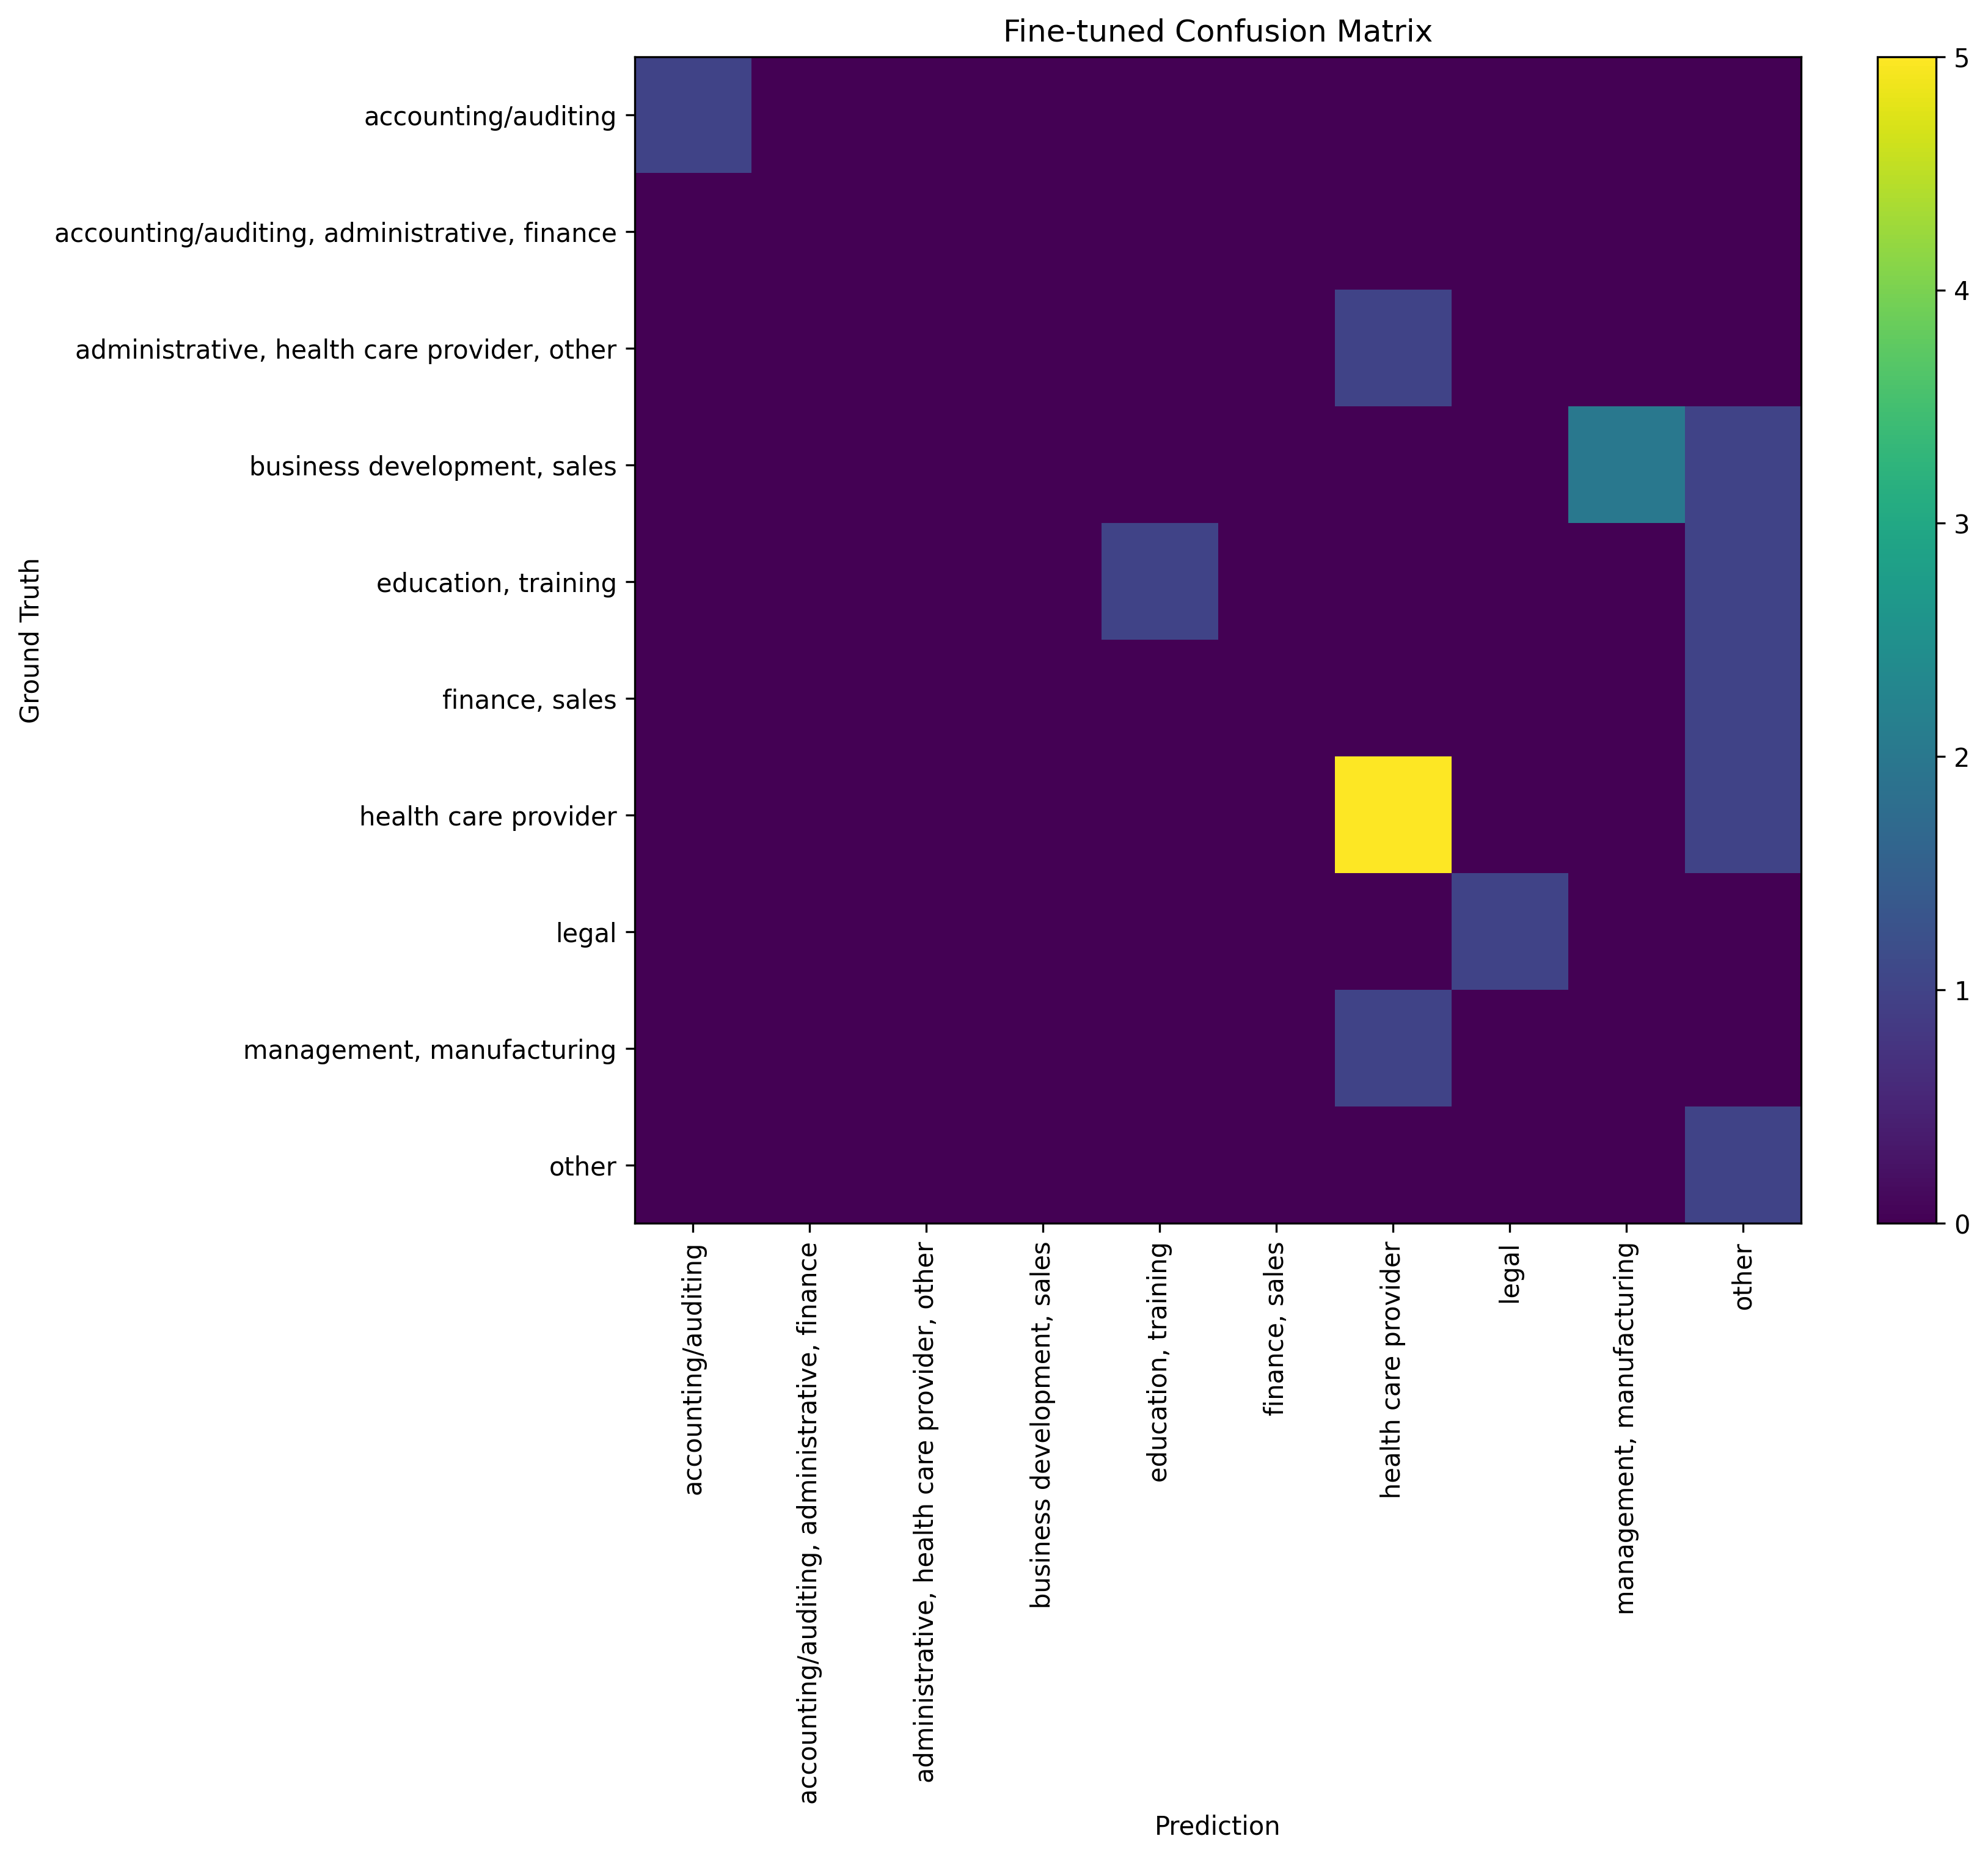

In [9]:
import pandas as pd
from IPython.display import Image, display

print("Prediction samples")
display(pd.read_csv("outputs/prediction_samples.csv").head())

print("Evaluation metrics")
display(pd.read_csv("outputs/evaluation/metrics.csv"))

display(Image(filename="outputs/evaluation/finetuned_confusion_matrix.png"))
